In [1]:
#Libraries for Machine Learning
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
fall = pd.read_csv('Dataset/fall.csv', header = None)
non_fall = pd.read_csv('Dataset/nf.csv', header = None)
rest = pd.read_csv('Dataset/rest.csv', header = None)

fall[0] = 1
non_fall[0] = 2
rest[0] = 3

fin = pd.concat([fall,non_fall,rest])
fin = fin.sample(frac = 1)

In [3]:
x_inp = fin.iloc[:,1:].values
y_inp = fin.iloc[:,0].values

In [4]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_inp,y_inp,random_state = 0)

In [5]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [6]:
from matplotlib.colors import ListedColormap

def LDA_Plot(x_val, y_val, x_test, y_test, func, step = 0.01, title = "Title", dpi = 800):
    plt.figure(dpi = dpi)
    
    x_set, y_set = x_val, y_val
    #To get a meshgrid for plotting on contour
    x1, x2 = np.meshgrid( np.arange(start = x_set[:,0].min() - 1, stop = x_set[:,0].max() + 1, step = step),
                          np.arange(start = x_set[:,1].min() - 1, stop = x_set[:,1].max() + 1, step = step))
    #Plotting on the contour
    Z = func(np.array([x1.ravel(), x2.ravel()]).T).reshape(x1.shape)
    plt.contourf(x1, x2, Z,
                 cmap = ListedColormap(('red', 'green', 'blue')), alpha = 0.75)
    #Limiting the plot to max & min units of x1 & x2
    plt.xlim(x1.min(), x1.max())
    plt.ylim(x2.min(), x2.max())
    plt.title("Decision Boundary - " + title)
    plt.savefig("Snips\\Decision Boundary - " + title)
    plt.show()
    
    plt.figure(dpi = dpi)
    
    plt.contourf(x1, x2, Z,
                 cmap = ListedColormap(('red', 'green', 'blue')), alpha = 0.75)
    #Limiting the plot to max & min units of x1 & x2
    plt.xlim(x1.min(), x1.max())
    plt.ylim(x2.min(), x2.max())
    #Scatter plot of y_val
    for i, j in enumerate(np.unique(y_test)):
        plt.scatter(x_test[y_test==j, 0], x_test[y_test==j, 1], 
                    color = ListedColormap(("#8B0000", 'green', '#0000A0'))(i), label= j, s = 0.5) #Dark Red & Blue for clear visibility
    plt.title( "Scatter Plot on Decision Boundary - " + title)
    plt.legend()
    plt.savefig("Snips\\Scatter Plot on Decision Boundary - " + title)
    plt.show()

## Data Visualisation

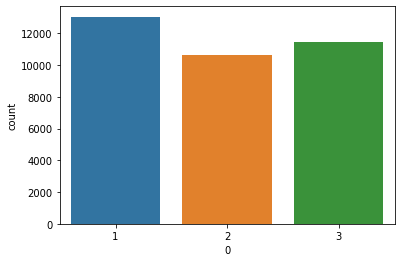

          0         1         2         3         4         5         6
0  1.000000 -0.125734  0.147766  0.456140 -0.029349 -0.160730 -0.032064
1 -0.125734  1.000000  0.125942 -0.241882  0.113857  0.063981  0.003829
2  0.147766  0.125942  1.000000 -0.014305  0.115320 -0.030169 -0.038072
3  0.456140 -0.241882 -0.014305  1.000000 -0.033405 -0.051677 -0.069031
4 -0.029349  0.113857  0.115320 -0.033405  1.000000  0.054885  0.090716
5 -0.160730  0.063981 -0.030169 -0.051677  0.054885  1.000000  0.131949
6 -0.032064  0.003829 -0.038072 -0.069031  0.090716  0.131949  1.000000


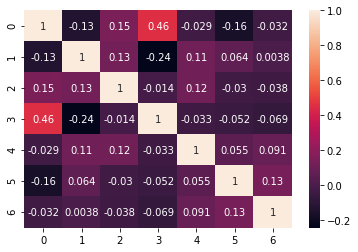

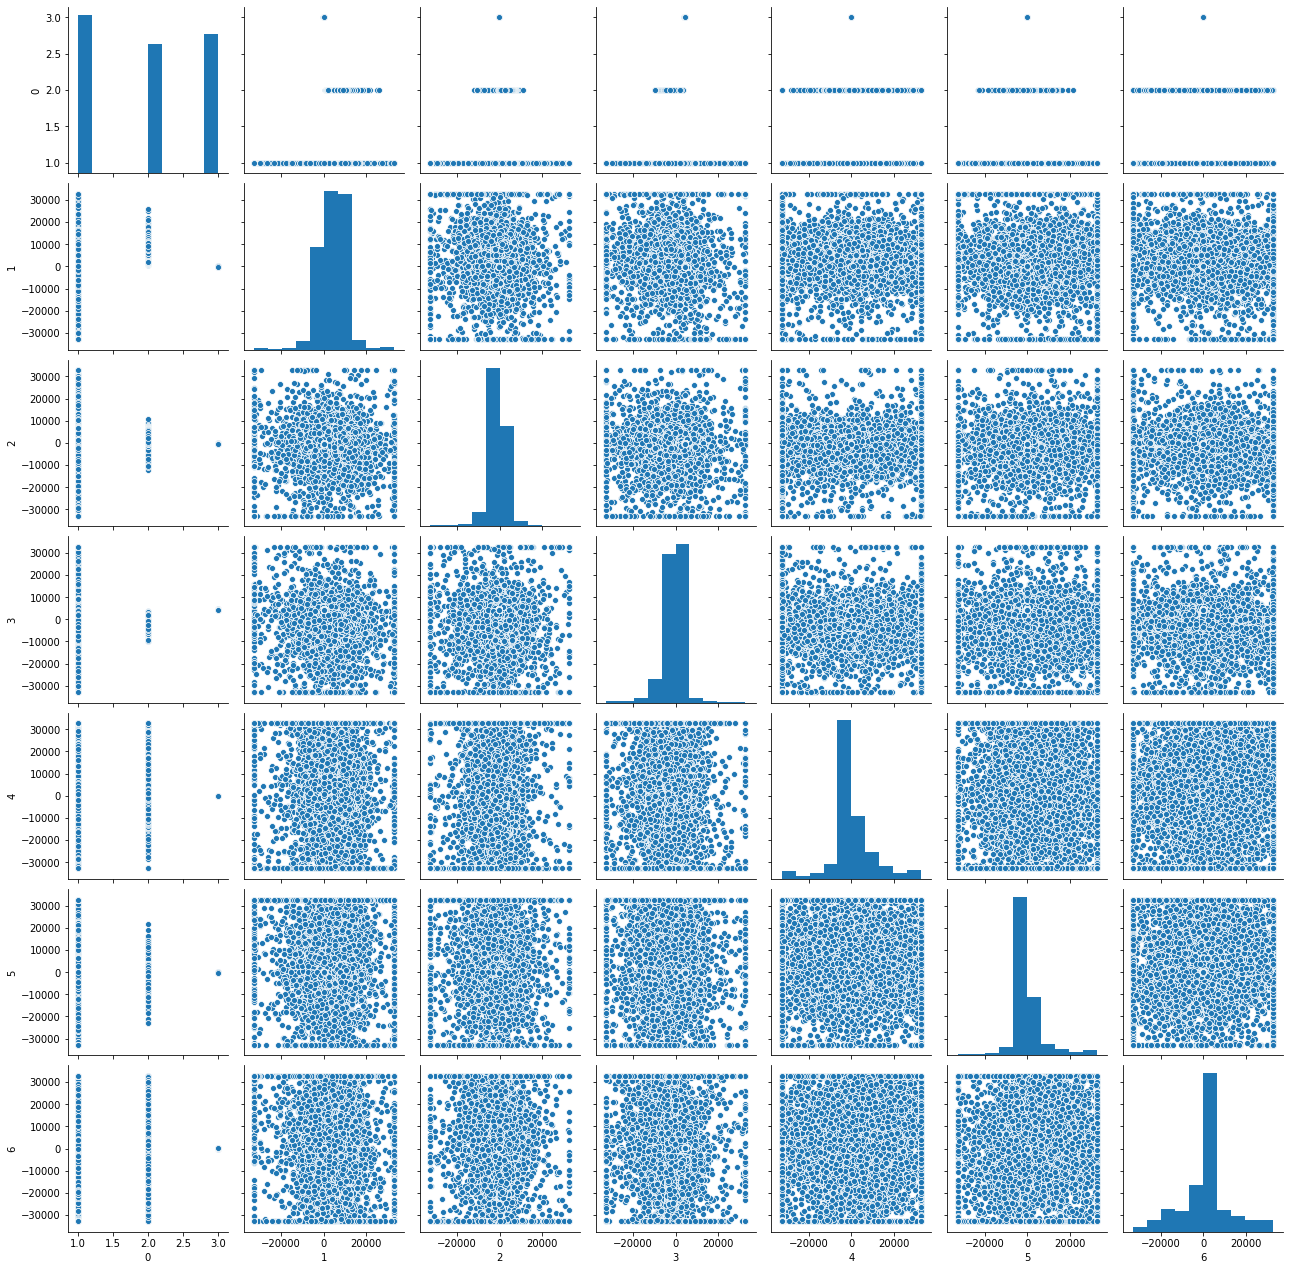

In [9]:
import seaborn as sns

#Count Plot
sns.countplot(fin[0])
plt.show()

#Heatmap of the data
correlation = fin.corr()
print(correlation)
sns.heatmap(correlation, annot=True)
plt.show()

#Pairplotting of all the parameters
sns.pairplot(fin)
plt.show()

## K Nearest Neighbors

In [10]:
from sklearn.neighbors import KNeighborsClassifier
classifier_kNN = KNeighborsClassifier(n_neighbors=10, metric='minkowski', p=2)
classifier_kNN.fit(x_train, y_train)

y_pred = classifier_kNN.predict(x_train)

In [8]:
#Confusion Matrix & Accuracy for evaluating the model for training data

from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
cm = confusion_matrix(y_train, y_pred)
print("Confusion Matrix (Train Data): \n", cm)

accuracy = accuracy_score(y_train, y_pred)
print("Accuracy (Train Data): {:.2f} %".format(accuracy*100))

Confusion Matrix (Train Data): 
 [[9479  292   10]
 [ 150 7866    0]
 [   0    0 8573]]
Accuracy (Train Data): 98.29 %


In [9]:
sen = np.array([ cm[0][0]/sum(cm[:, 0]), cm[1][1]/sum(cm[:, 1]), cm[2][2]/sum(cm[:, 2]) ])
print("Sensitivity of Fall for Train Data: ", sen[0])
print("Sensitivity of Non-Fall for Train Data: ", sen[1])
print("Sensitivity of Rest for Train Data: ", sen[2])
print("Sensitivity of Train Data: ", sen.mean()*100, "%")

spec = np.array([ (cm[1][1] + cm[2][2])/(sum(cm[:, 1]) + sum(cm[:, 2])), 
                  (cm[0][0] + cm[2][2])/(sum(cm[:, 0]) + sum(cm[:, 2])),
                  (cm[0][0] + cm[1][1])/(sum(cm[:, 0]) + sum(cm[:, 1]))
                ])
print("Specificity of Fall for Train Data: ", spec[0] )
print("Specificity of Non-Fall for Train Data: ",  spec[1] )
print("Specificity of Rest for Train Data: ",  spec[2])
print("Specificity of Train Data: ", spec.mean()*100, "%")

Sensitivity of Fall for Train Data:  0.9844220583653547
Sensitivity of Non-Fall for Train Data:  0.9642069134591812
Sensitivity of Rest for Train Data:  0.9988349062099499
Sensitivity of Train Data:  98.24879593448284 %
Specificity of Fall for Train Data:  0.9819604563646138
Specificity of Non-Fall for Train Data:  0.9912145837909071
Specificity of Rest for Train Data:  0.9751503907348064
Specificity of Train Data:  98.27751436301092 %


In [10]:
# Confusion Matrix & Accuracy for evaluating the model for test data

y_pred = classifier_kNN.predict(x_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (Test Data): \n", cm)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy (Test Data): {:.2f} %".format(accuracy*100))

Confusion Matrix (Test Data): 
 [[3149  123    4]
 [  71 2577    0]
 [   0    0 2867]]
Accuracy (Test Data): 97.75 %


In [11]:
sen = np.array([ cm[0][0]/sum(cm[:, 0]), cm[1][1]/sum(cm[:, 1]), cm[2][2]/sum(cm[:, 2]) ])
print("Sensitivity of Fall for Test Data: ", sen[0])
print("Sensitivity of Non-Fall for Test Data: ", sen[1])
print("Sensitivity of Rest for Test Data: ", sen[2])
print("Sensitivity of Test Data: ", sen.mean()*100, "%")

spec = np.array([ (cm[1][1] + cm[2][2])/(sum(cm[:, 1]) + sum(cm[:, 2])), 
                  (cm[0][0] + cm[2][2])/(sum(cm[:, 0]) + sum(cm[:, 2])),
                  (cm[0][0] + cm[1][1])/(sum(cm[:, 0]) + sum(cm[:, 1]))
                ])
print("Specificity of Fall for Test Data: ", spec[0] )
print("Specificity of Non-Fall for Test Data: ",  spec[1] )
print("Specificity of Rest for Test Data: ",  spec[2])
print("Specificity of Test Data: ", spec.mean()*100, "%")

Sensitivity of Fall for Test Data:  0.9779503105590062
Sensitivity of Non-Fall for Test Data:  0.9544444444444444
Sensitivity of Rest for Test Data:  0.9986067572274469
Sensitivity of Test Data:  97.70005040769658 %
Specificity of Fall for Test Data:  0.9772033746185604
Specificity of Non-Fall for Test Data:  0.9876867509440158
Specificity of Rest for Test Data:  0.9672297297297298
Specificity of Test Data:  97.73732850974353 %


In [12]:
# 10 Fold CV accuracy

from sklearn.model_selection import cross_val_score

accuracies = cross_val_score(estimator=classifier_kNN, X=x_inp, y=y_inp, cv=10, n_jobs=-1)
print("Mean of Accuracies: {:.2f} %".format(accuracies.mean()*100))
print("Std of Accuracies: ", accuracies.std())

Mean of Accuracies: 97.51 %
Std of Accuracies:  0.0023152113037812672


In [13]:
# Choosing k, such that 98% of the variance is reatined.
# But, here even for k = 1, 100% variance is retained. So, for better data visualisation k=2 is chosen
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
lda = LDA(n_components=2)
# Transforming z_train & z_test using the new reduced dimension vector (U_reduce)
z_train = lda.fit_transform(x_train, y_train)
z_test = lda.transform(x_test)

In [14]:
# Analysing the SVM model fit with z_train
classifier_z = KNeighborsClassifier(n_neighbors=10, metric='minkowski', p=2)
classifier_z.fit(z_train, y_train)
y_z_pred = classifier_z.predict(z_train)

In [15]:
cm = confusion_matrix(y_z_pred, y_train)
print("Confustion Matrix (Z-Test Data): \n", cm)
accuracy = accuracy_score(y_train, y_z_pred)
print("Accuracy (Z-Train Data): {:.2f} %".format(accuracy*100))

Confustion Matrix (Z-Test Data): 
 [[8961  641    0]
 [ 801 7375    0]
 [  19    0 8573]]
Accuracy (Z-Train Data): 94.46 %


In [16]:
y_z_pred = classifier_z.predict(z_test)

cm = confusion_matrix(y_test, y_z_pred)
print("Confusion Matrix (Test Data): \n", cm)
accuracy = accuracy_score(y_test, y_z_pred)
print("Accuracy (Z-Test Data): {:.2f} %".format(accuracy*100))

Confusion Matrix (Test Data): 
 [[2952  317    7]
 [ 268 2380    0]
 [   0    0 2867]]
Accuracy (Z-Test Data): 93.27 %


In [17]:
# 10_Fold CV accuracy

z_inp = lda.transform(x_inp)

accuracies = cross_val_score(estimator=classifier_z, X=z_inp, y=y_inp, cv=10, n_jobs=-1)
print("Mean of Accuracies: {:.2f} %".format(accuracies[1:].mean()*100))
print("Std of Accuracies: ", accuracies[1:].std())

Mean of Accuracies: 92.89 %
Std of Accuracies:  0.004731589469561122


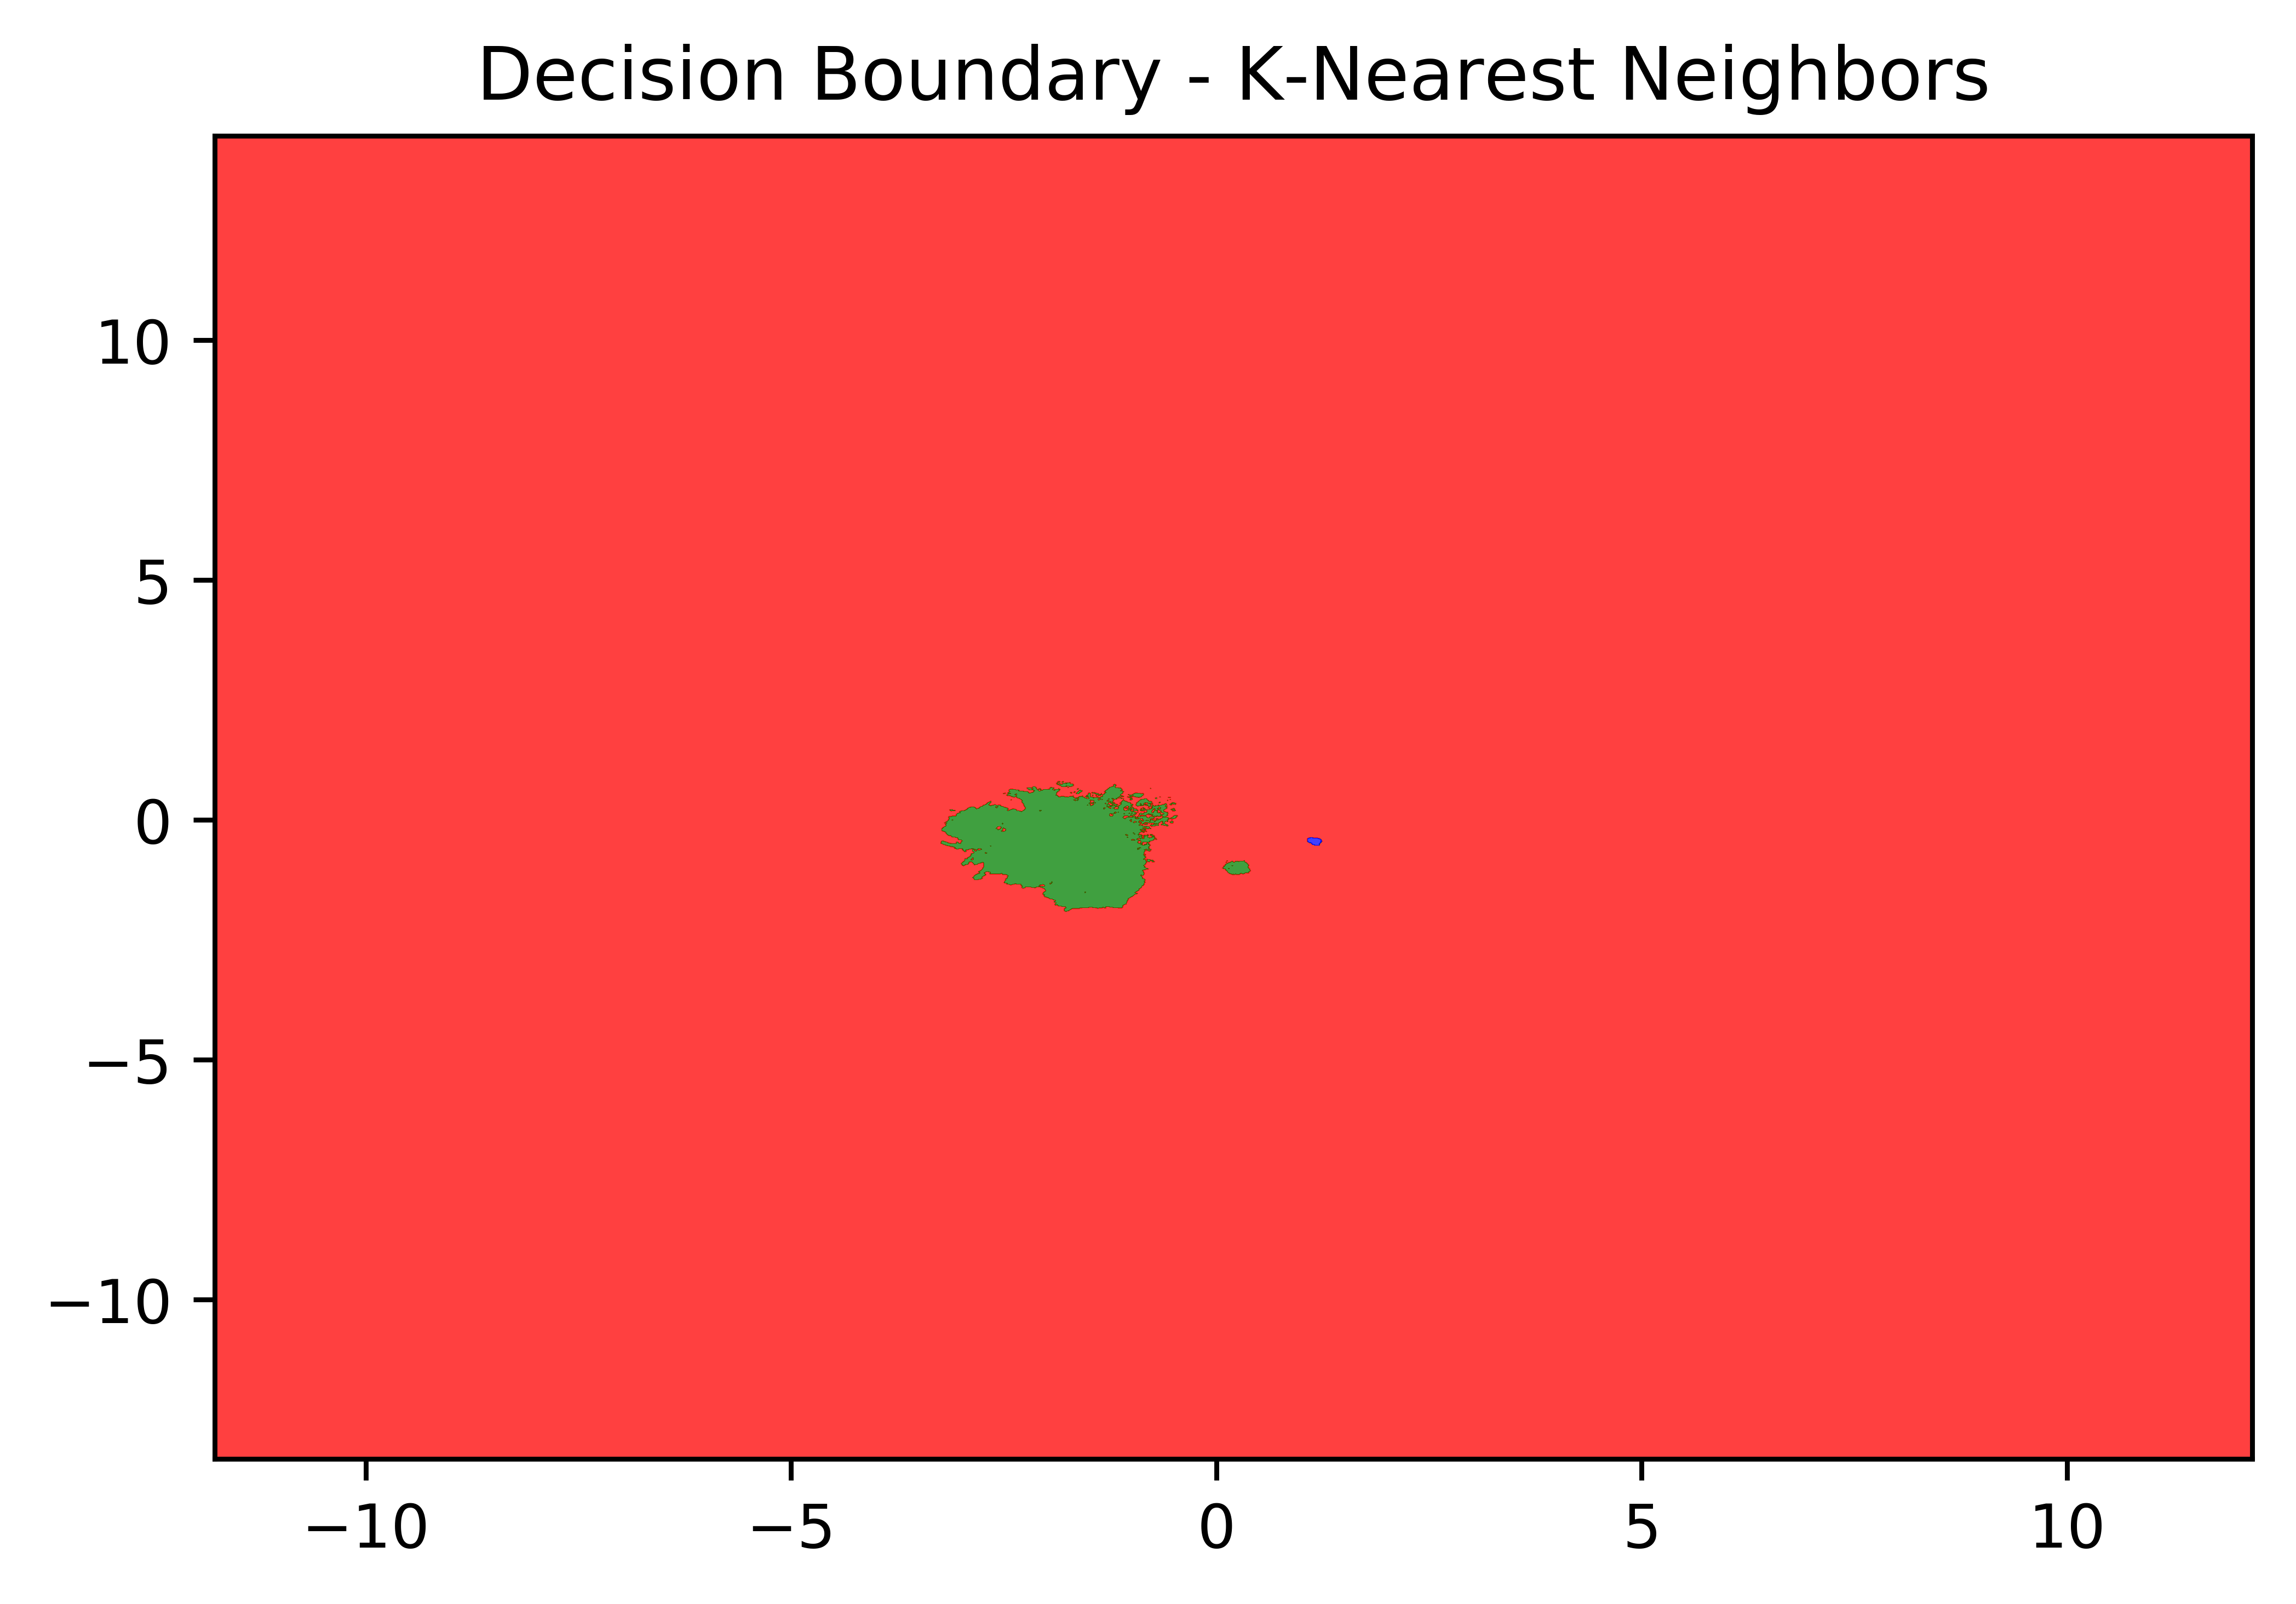

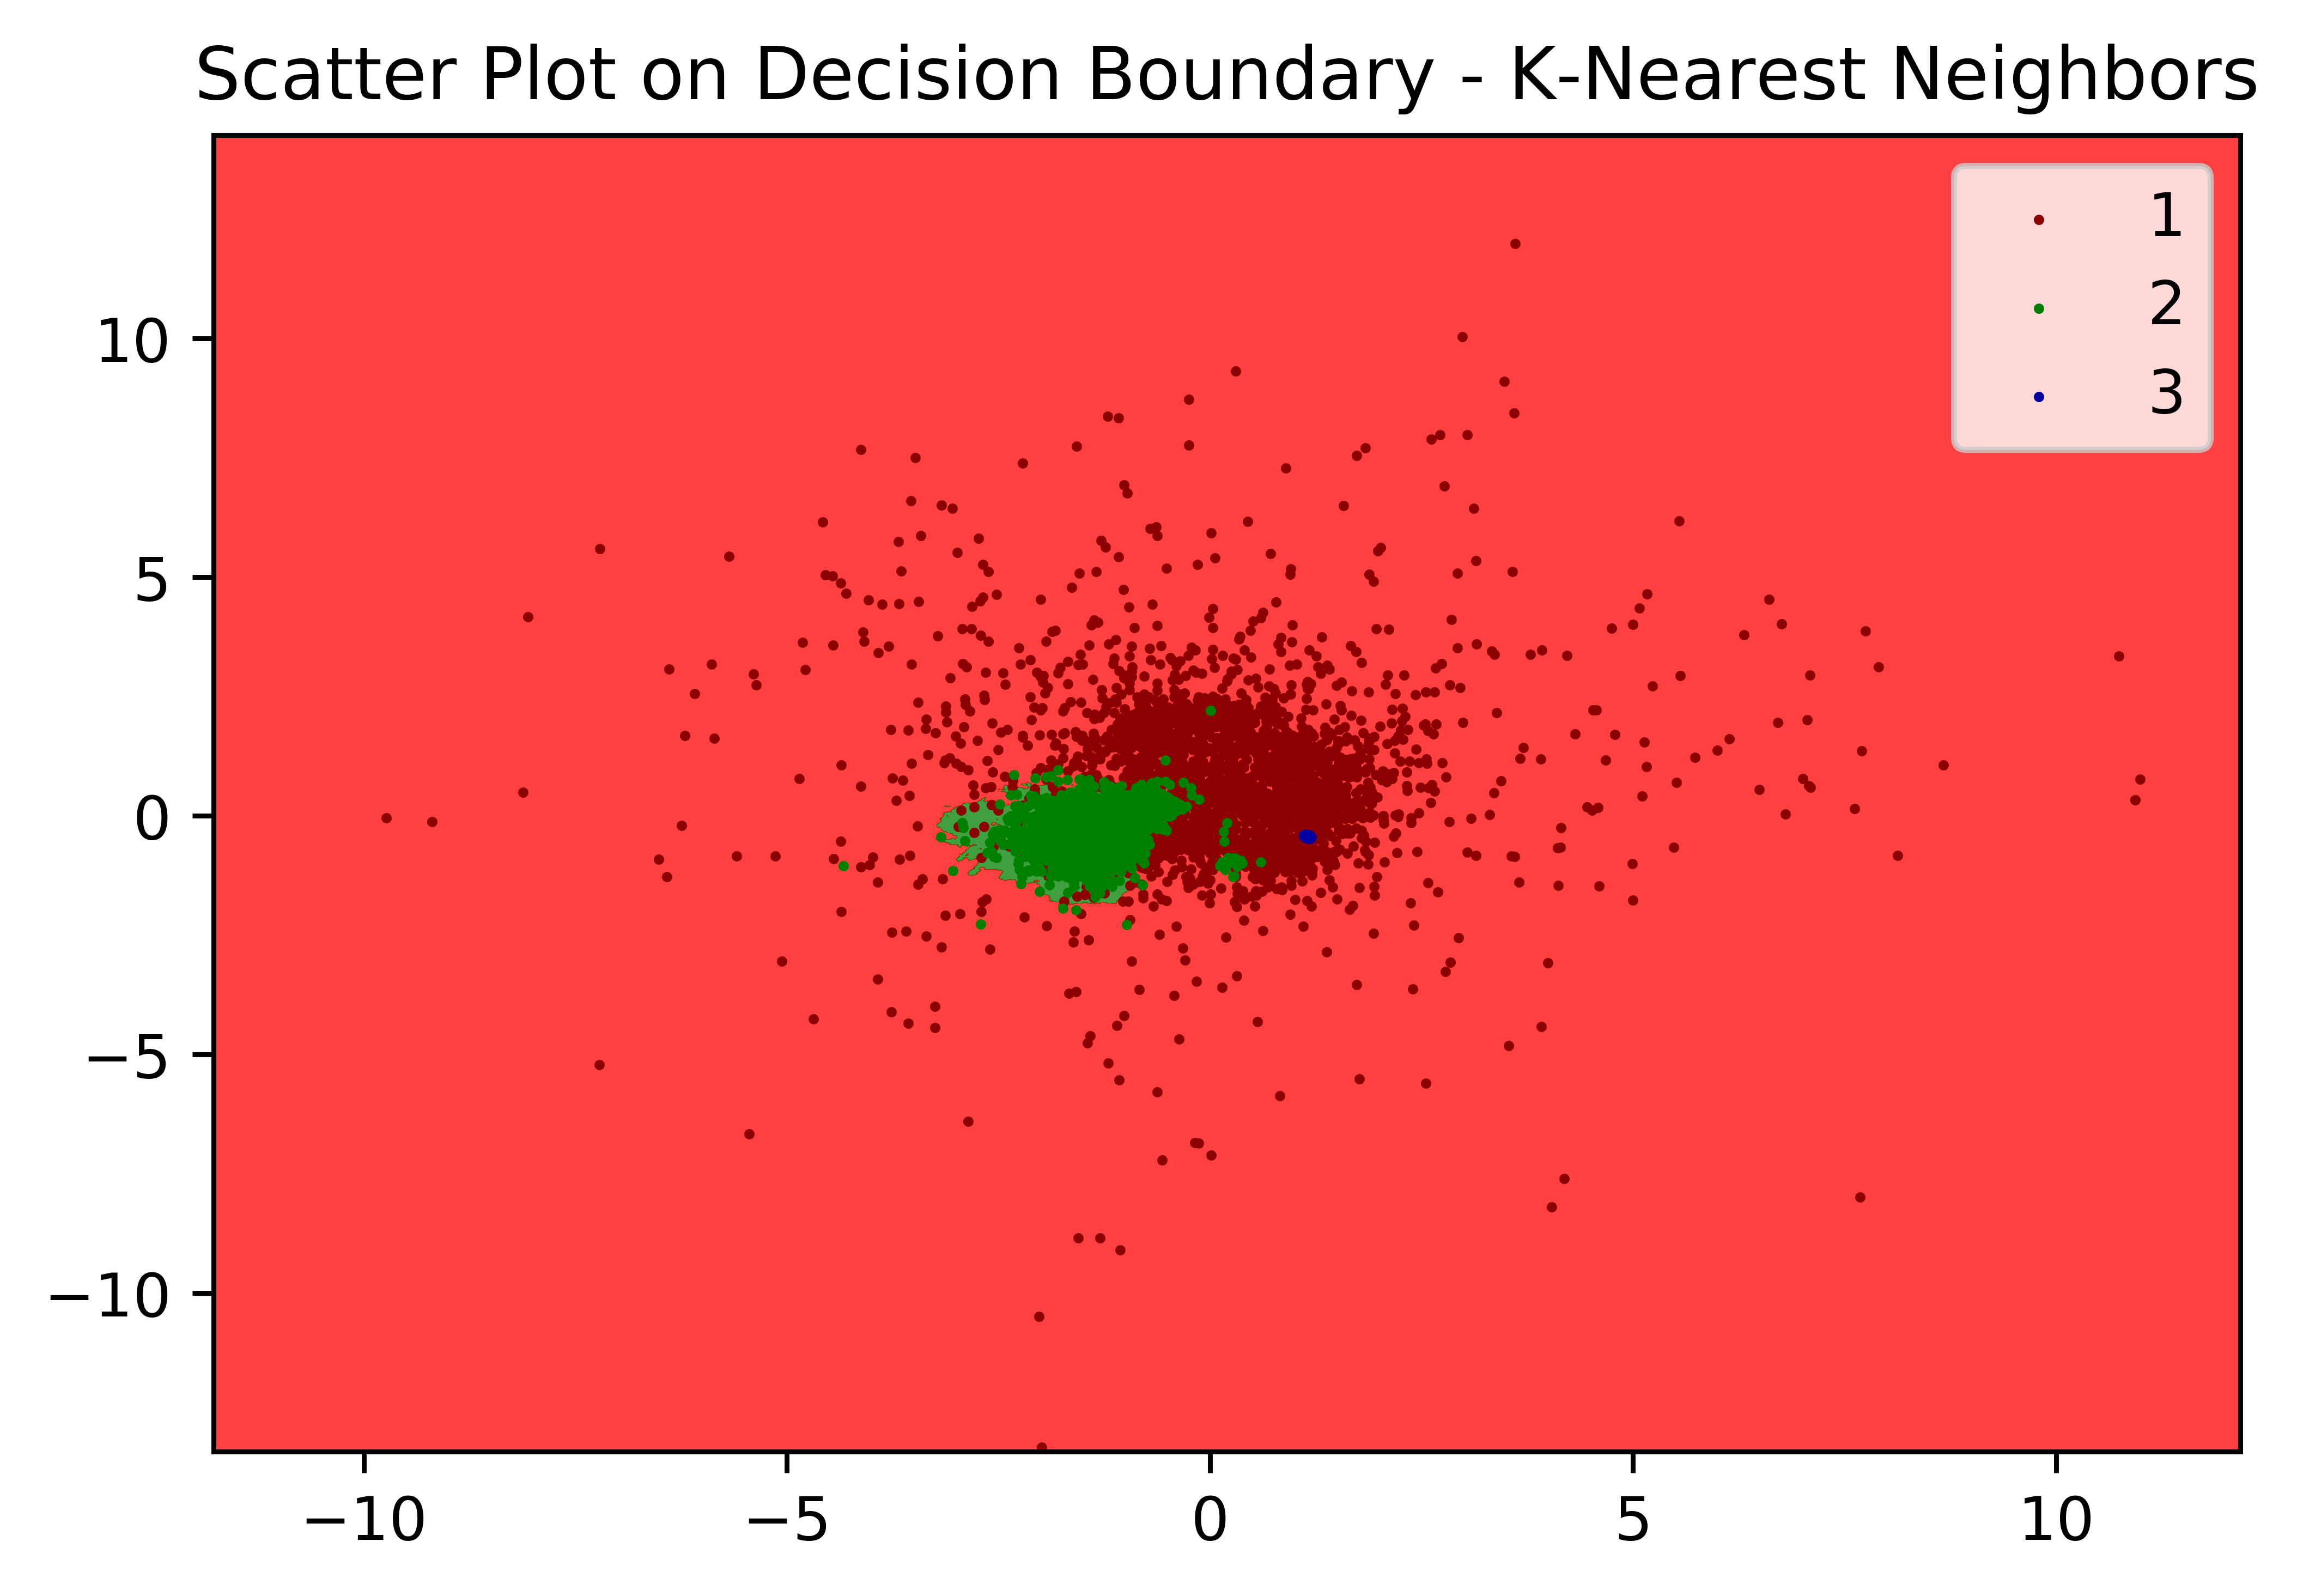

In [35]:
LDA_Plot(z_train, y_train, z_test, y_test, func = classifier_z.predict ,title = "K-Nearest Neighbors")

## XGBoost

In [11]:
from xgboost import XGBClassifier
classifier_XG = XGBClassifier(n_estimators = 600, max_depth = 10, n_jobs = 1)
classifier_XG.fit(x_train, y_train)

y_pred = classifier_XG.predict(x_train)

In [50]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_train, y_pred)
print("Confusion Matrix (Train Data): \n", cm)

accuracy = accuracy_score(y_train, y_pred)
print("Accuracy (Train Data): {:.2f} %".format(accuracy*100))

Confusion Matrix (Train Data): 
 [[9820    0    0]
 [   0 7999    0]
 [   0    0 8551]]
Accuracy (Train Data): 100.00 %


In [51]:
sen = np.array([ cm[0][0]/sum(cm[:, 0]), cm[1][1]/sum(cm[:, 1]), cm[2][2]/sum(cm[:, 2]) ])
print("Sensitivity of Fall for Train Data: ", sen[0])
print("Sensitivity of Non-Fall for Train Data: ", sen[1])
print("Sensitivity of Rest for Train Data: ", sen[2])
print("Sensitivity of Train Data: ", sen.mean()*100, "%")

spec = np.array([ (cm[1][1] + cm[2][2])/(sum(cm[:, 1]) + sum(cm[:, 2])), 
                  (cm[0][0] + cm[2][2])/(sum(cm[:, 0]) + sum(cm[:, 2])),
                  (cm[0][0] + cm[1][1])/(sum(cm[:, 0]) + sum(cm[:, 1]))
                ])
print("Specificity of Fall for Train Data: ", spec[0] )
print("Specificity of Non-Fall for Train Data: ",  spec[1] )
print("Specificity of Rest for Train Data: ",  spec[2])
print("Specificity of Train Data: ", spec.mean()*100, "%")

Sensitivity of Fall for Train Data:  1.0
Sensitivity of Non-Fall for Train Data:  1.0
Sensitivity of Rest for Train Data:  1.0
Sensitivity of Train Data:  100.0 %
Specificity of Fall for Train Data:  1.0
Specificity of Non-Fall for Train Data:  1.0
Specificity of Rest for Train Data:  1.0
Specificity of Train Data:  100.0 %


In [52]:
# Confusion Matrix & Accuracy for evaluating the model for test data

y_pred = classifier_XG.predict(x_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (Test Data): \n", cm)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy (Test Data): {:.2f} %".format(accuracy*100))

Confusion Matrix (Test Data): 
 [[3170   63    4]
 [  63 2602    0]
 [   0    0 2889]]
Accuracy (Test Data): 98.52 %


In [53]:
sen = np.array([ cm[0][0]/sum(cm[:, 0]), cm[1][1]/sum(cm[:, 1]), cm[2][2]/sum(cm[:, 2]) ])
print("Sensitivity of Fall for Test Data: ", sen[0])
print("Sensitivity of Non-Fall for Test Data: ", sen[1])
print("Sensitivity of Rest for Test Data: ", sen[2])
print("Sensitivity of Test Data: ", sen.mean()*100, "%")

spec = np.array([ (cm[1][1] + cm[2][2])/(sum(cm[:, 1]) + sum(cm[:, 2])), 
                  (cm[0][0] + cm[2][2])/(sum(cm[:, 0]) + sum(cm[:, 2])),
                  (cm[0][0] + cm[1][1])/(sum(cm[:, 0]) + sum(cm[:, 1]))
                ])
print("Specificity of Fall for Test Data: ", spec[0] )
print("Specificity of Non-Fall for Test Data: ",  spec[1] )
print("Specificity of Rest for Test Data: ",  spec[2])
print("Specificity of Test Data: ", spec.mean()*100, "%")

Sensitivity of Fall for Test Data:  0.9805134549953604
Sensitivity of Non-Fall for Test Data:  0.976360225140713
Sensitivity of Rest for Test Data:  0.9986173522295195
Sensitivity of Test Data:  98.51636774551976 %
Specificity of Fall for Test Data:  0.9879453040662108
Specificity of Non-Fall for Test Data:  0.9890630101207966
Specificity of Rest for Test Data:  0.9786368260427264
Specificity of Test Data:  98.52150467432446 %


In [23]:
#10 Fold Cross Validation

from sklearn.model_selection import cross_val_score

accuracies = cross_val_score(estimator=classifier_XG, X=x_inp, y=y_inp, cv=10, n_jobs=-1)
print("Mean of Accuracies: {:.2f} %".format(accuracies[1:].mean()*100))
print("Std of Accuracies: ", accuracies[1:].std())

Mean of Accuracies: 98.42 %
Std of Accuracies:  0.0020155756186451762


In [24]:
# Choosing k, such that 98% of the variance is reatined.
# But, here even for k = 1, 100% variance is retained. So, for better data visualisation k=2 is chosen

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
lda = LDA(n_components=2)
# Transforming z_train & z_test using the new reduced dimension vector (U_reduce)
z_train = lda.fit_transform(x_train, y_train)
z_test = lda.transform(x_test)

In [25]:
# Analysing the SVM model fit with z_train
classifier_z = XGBClassifier(n_estimators = 600, max_depth = 10, n_jobs = 1)
classifier_z.fit(z_train, y_train)
y_z_pred = classifier_z.predict(z_train)

In [26]:
cm = confusion_matrix(y_z_pred, y_train)
print("Confustion Matrix (Z-Test Data): \n", cm)
accuracy = accuracy_score(y_train, y_z_pred)
print("Accuracy (Z-Train Data): {:.2f} %".format(accuracy*100))

Confustion Matrix (Z-Test Data): 
 [[9597   12    0]
 [ 184 8004    0]
 [   0    0 8573]]
Accuracy (Z-Train Data): 99.26 %


In [27]:
y_z_pred = classifier_z.predict(z_test)

cm = confusion_matrix(y_test, y_z_pred)
print("Confusion Matrix (Test Data): \n", cm)
accuracy = accuracy_score(y_test, y_z_pred)
print("Accuracy (Z-Test Data): {:.2f} %".format(accuracy*100))

Confusion Matrix (Test Data): 
 [[2886  388    2]
 [ 231 2417    0]
 [   3    0 2864]]
Accuracy (Z-Test Data): 92.90 %


In [28]:
# 10_Fold CV accuracy

z_inp = lda.transform(x_inp)

accuracies = cross_val_score(estimator=classifier_z, X=z_inp, y=y_inp, cv=10, n_jobs=-1)
print("Mean of Accuracies: {:.2f} %".format(accuracies[1:].mean()*100))
print("Std of Accuracies: ", accuracies[1:].std())

Mean of Accuracies: 92.75 %
Std of Accuracies:  0.0037718559136299566


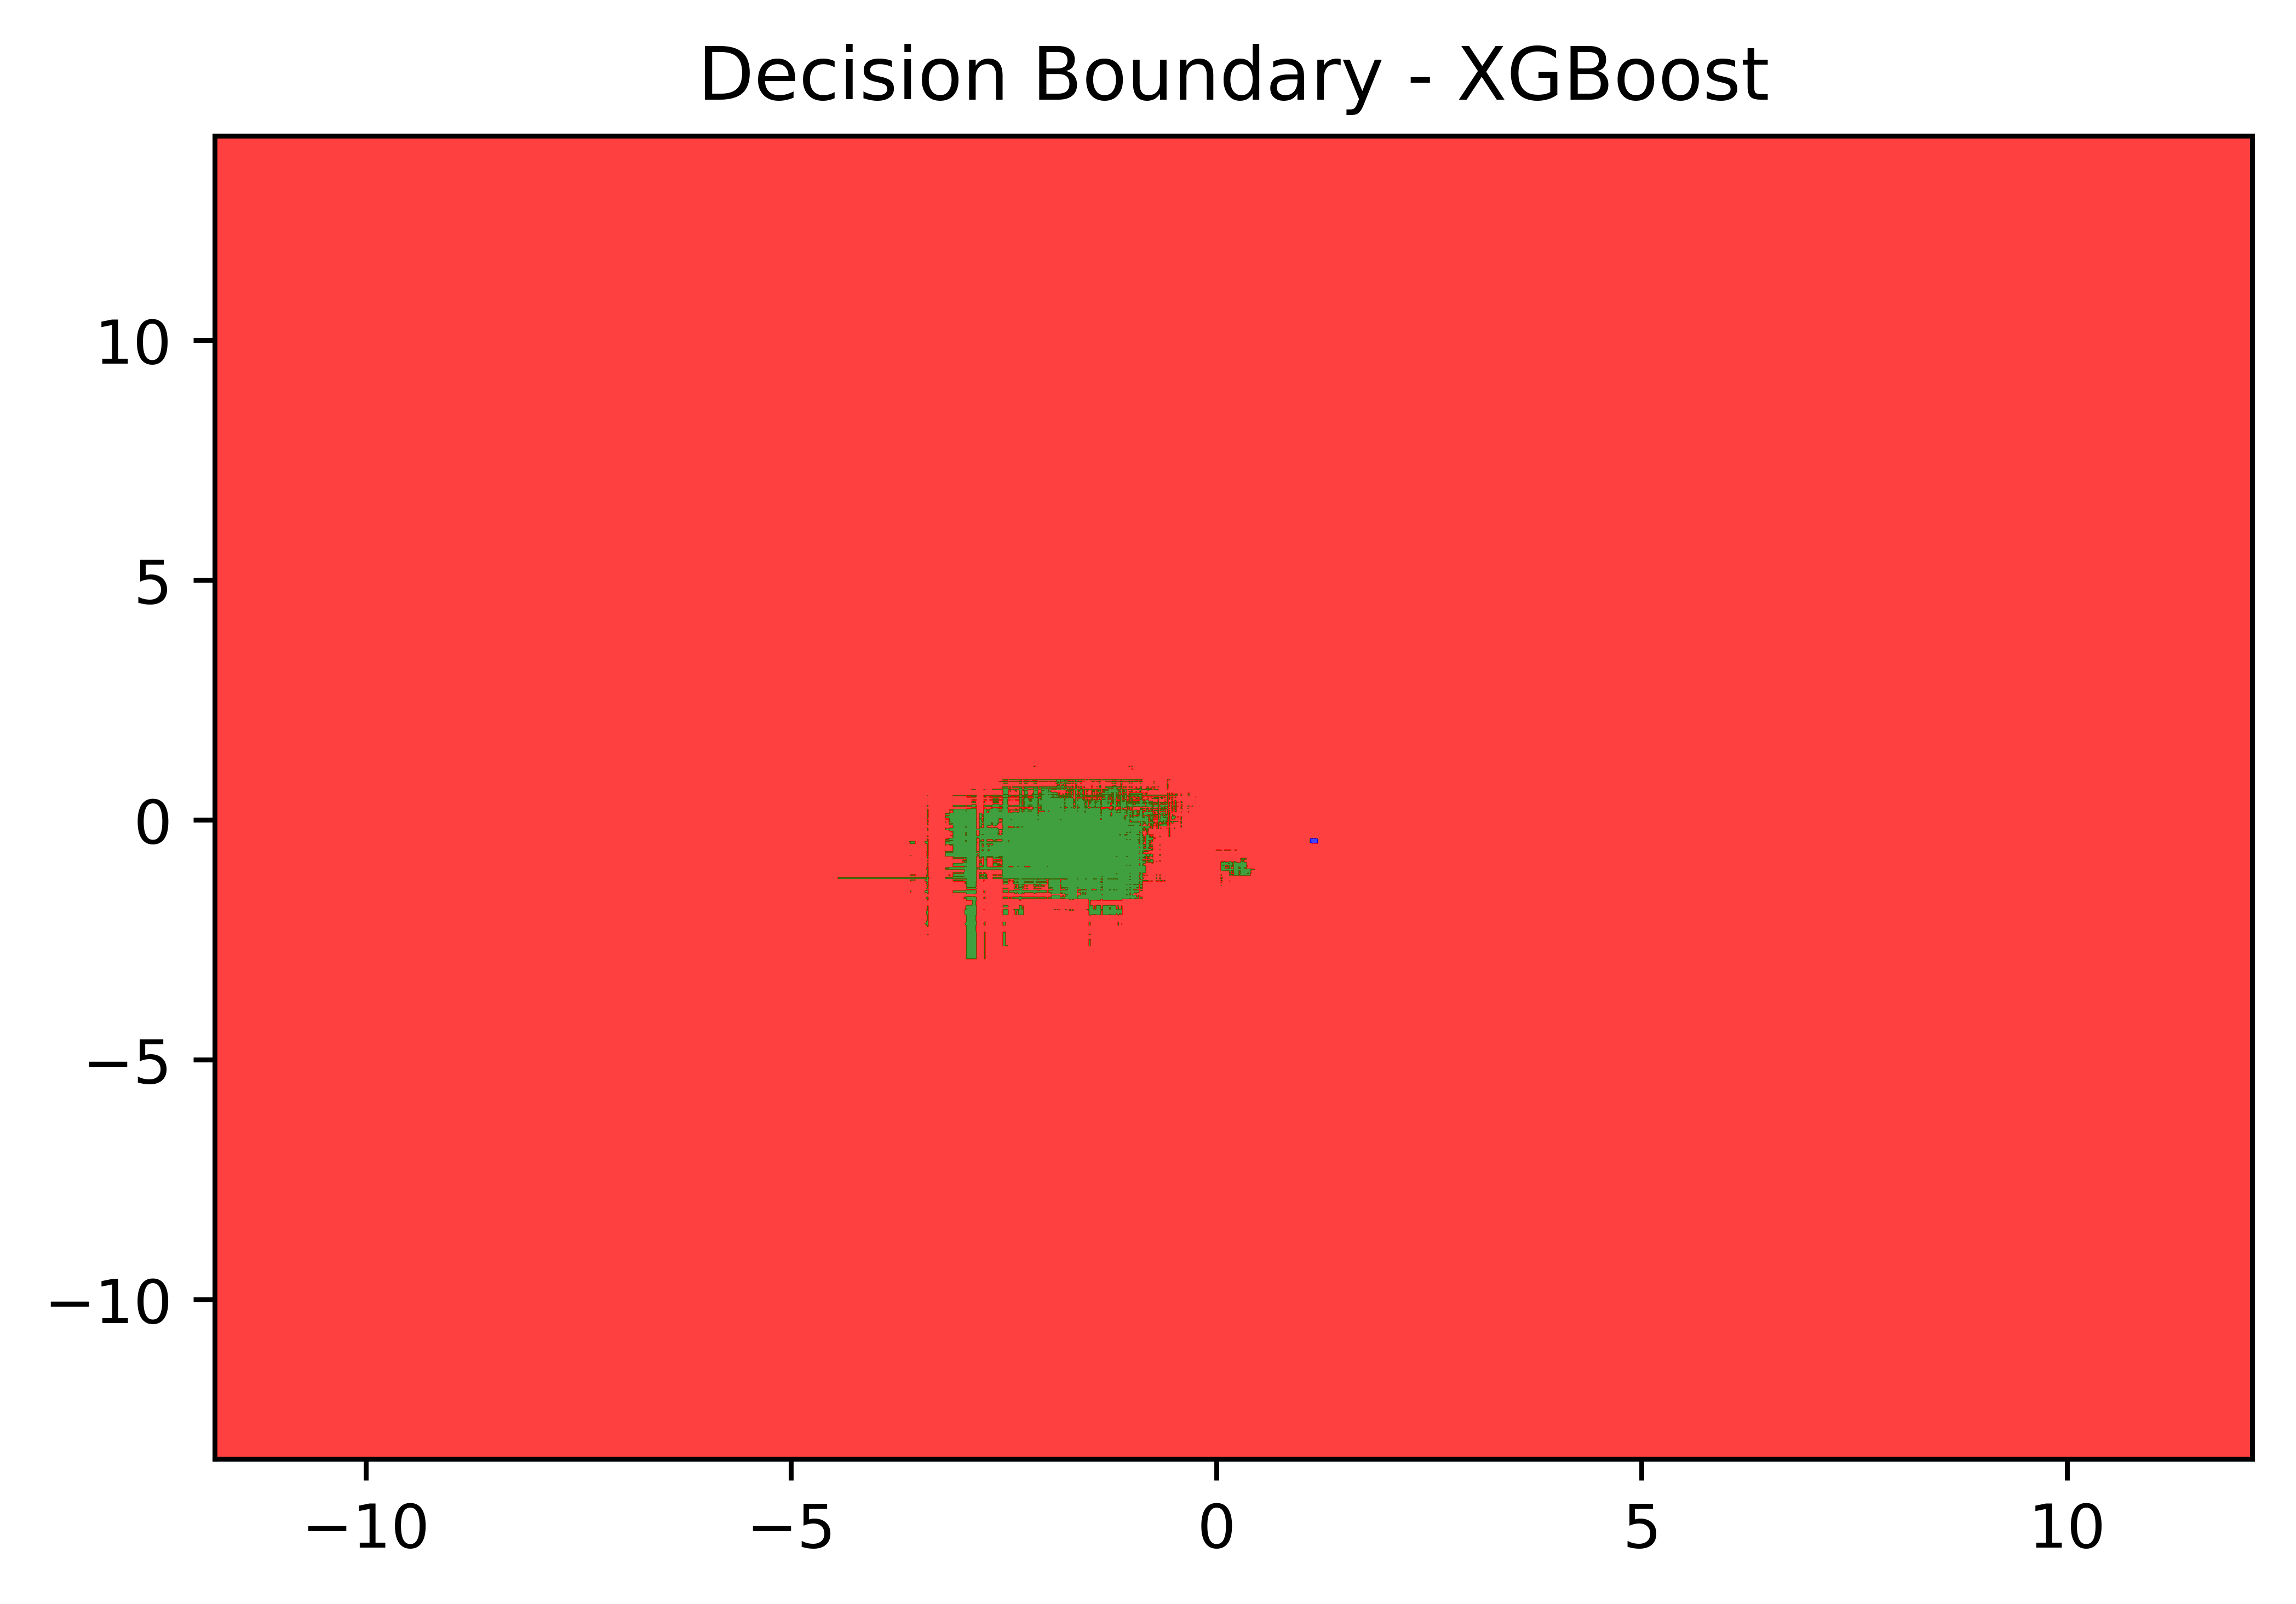

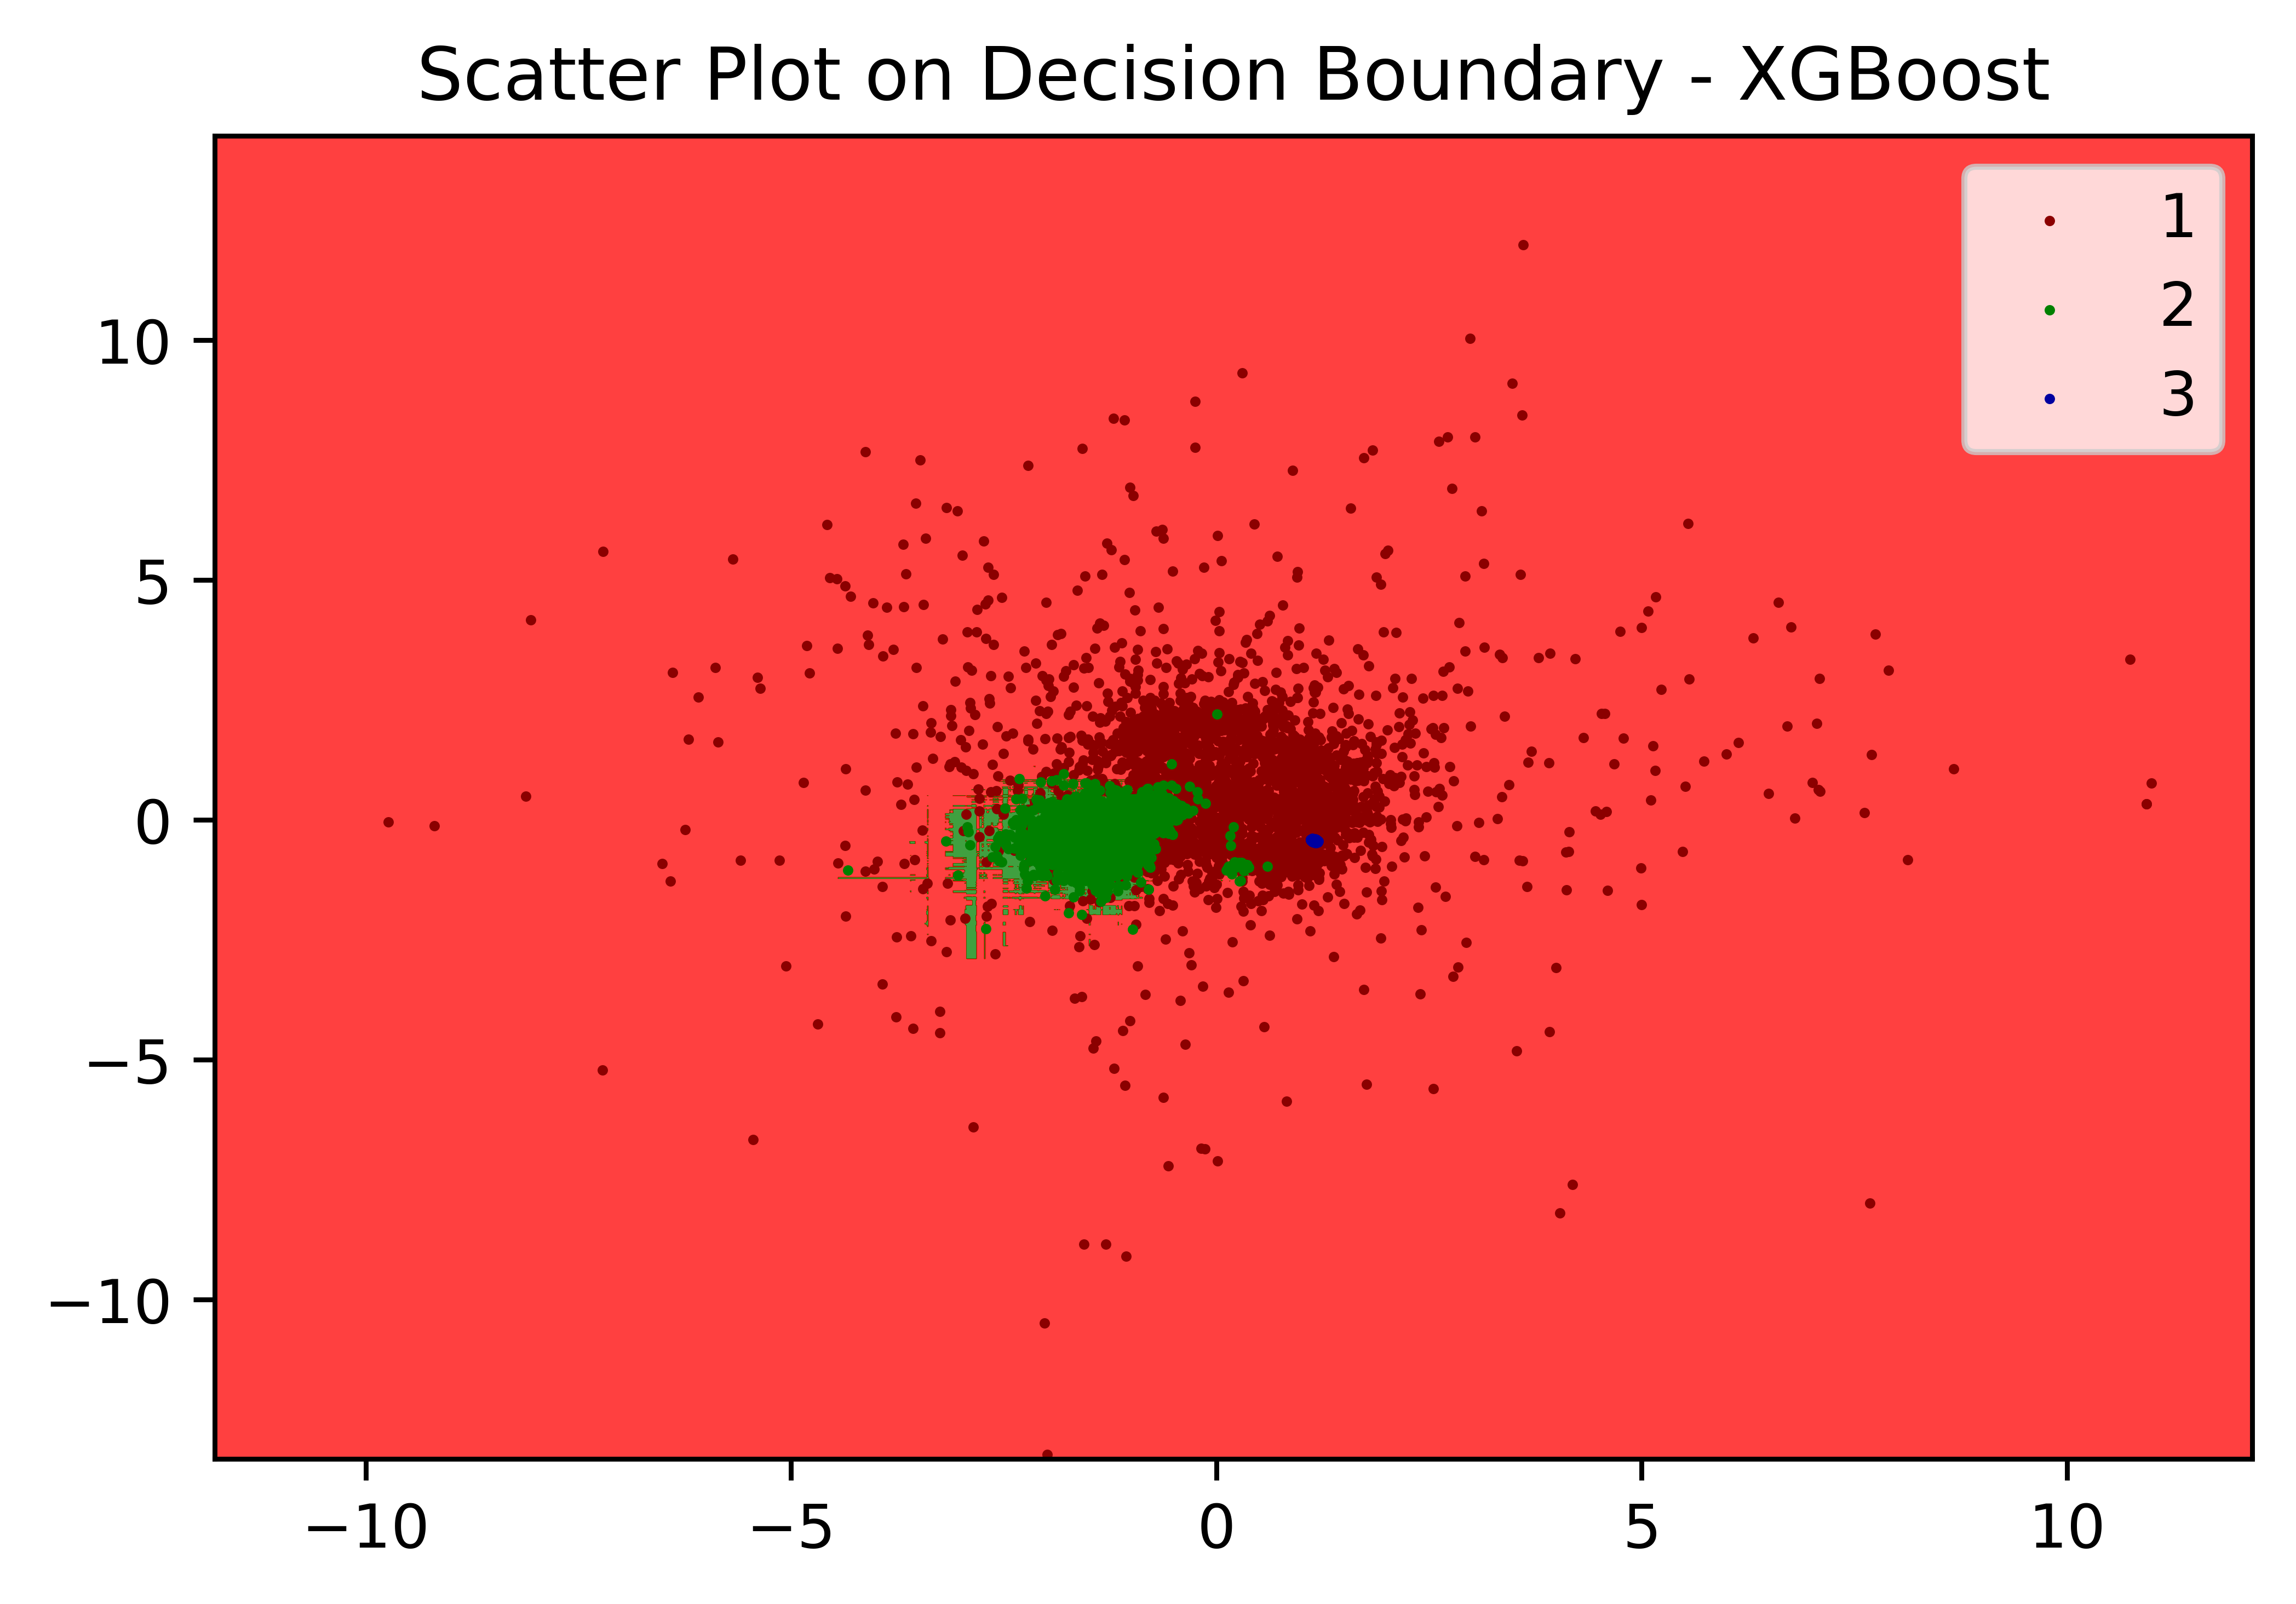

In [18]:
LDA_Plot(z_train, y_train, z_test, y_test, func = classifier_z.predict ,title = "XGBoost")

## Validation

In [16]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

accuracies_k = []
accuracies_xg = []

for i in range(5):
    x_v = sc.transform(pd.read_csv("Validation_Set/" + str(i+1) + "f_v.csv", header=None).iloc[:,1:].values)
    
    y_pred = classifier_kNN.predict(x_v)
    accuracies_k.append( (sum(y_pred == 1)/len(y_pred))*100 )
    
    y_pred = classifier_XG.predict(x_v)
    accuracies_xg.append( (sum(y_pred == 1)/len(y_pred))*100 )

x_v = sc.transform(pd.read_csv("Validation_Set/nf_v.csv", header=None).iloc[:,1:].values)

y_pred = classifier_kNN.predict(x_v)
accuracies_k.append( (sum(y_pred == 2)/len(y_pred))*100 )

y_pred = classifier_XG.predict(x_v)
accuracies_xg.append( (sum(y_pred == 2)/len(y_pred))*100 )

print("Accuarcy of KNN on Validation Set: " , sum(accuracies_k)/len(accuracies_k), "%")
print("Accuarcy of XGBoost on Validation Set: " , sum(accuracies_xg)/len(accuracies_xg), "%")

Accuarcy of KNN on Validation Set:  96.73985549212654 %
Accuarcy of XGBoost on Validation Set:  98.67578347578348 %


## Testing on Live Data

In [18]:
def Call(GSMPort):
    print("Calling Hospital")
    
    GSMPort.write(b'ATZ\r')
    time.sleep(0.5)
    
    winsound.Beep(800,500)
    
    GSMPort.write(b'AT+CMGF=1\r')
    time.sleep(0.5)
    
    GSMPort.write(b'ATD+918919029787;\r')
    time.sleep(20)
    
    GSMPort.write(b'ATH\r')
    time.sleep(0.5)

    GSMPort.write(chr(26))
    time.sleep(0.5)
    
    GSMPort.close()

In [21]:
bandPort.close()
GSMPort.close()

In [20]:
import winsound
import serial, time

bandPort = serial.Serial(port = "COM5", baudrate=9600, timeout=0.1, stopbits=serial.STOPBITS_ONE)

x_inp = []
FALL_THRES = 100

while(1):
    if(bandPort.in_waiting > 0):
        try:
            serialString = bandPort.readline().strip().decode("utf-8")
            inp = serialString.split(",")
            inp = list(map(int, inp))[1:]
            #inp = np.asarray(list(map(int, inp))[1:])
            #print(inp)
            
            if(len(inp) == 6 and len(x_inp) < FALL_THRES):
                x_inp.append(inp)
                
            elif(len(x_inp) >= FALL_THRES): 
                y_pred = classifier_XG.predict(sc.transform(np.asarray(x_inp)))
                out = np.bincount(y_pred).argmax()
                if (out == 1):
                    GSMPort = serial.Serial("COM4" , 9600 , timeout = .1)#Port of GSM Module
                    print("Its a Fall")
                    Call(GSMPort)
                elif(out == 2):
                    print("Its a non-Fall")
                elif(out == 3):
                    print("At Rest")
                bandPort.flush()
                x_inp = []
                continue
                
            else:
                continue
                
        except Exception:
            continue   

Its a Fall
Calling Hospital


KeyboardInterrupt: 